In [ ]:
#| default_exp core

In [ ]:
#| export
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

def run(qc, shots):
  simulator = AerSimulator()
  tqc = transpile(qc, simulator, optimization_level=3)

  job = simulator.run(tqc, shots=shots)
  result = job.result()

  return dict(sorted(result.get_counts().items()))

Fedoriaka implements the $MAJ$ and $MAJ^{-1}$ gates efficiently by incorporating the $AND$ and $AND^{-1}$ gates described in "Halving the cost of quantum addition" (Gidney). Below is the implementation of said gates.

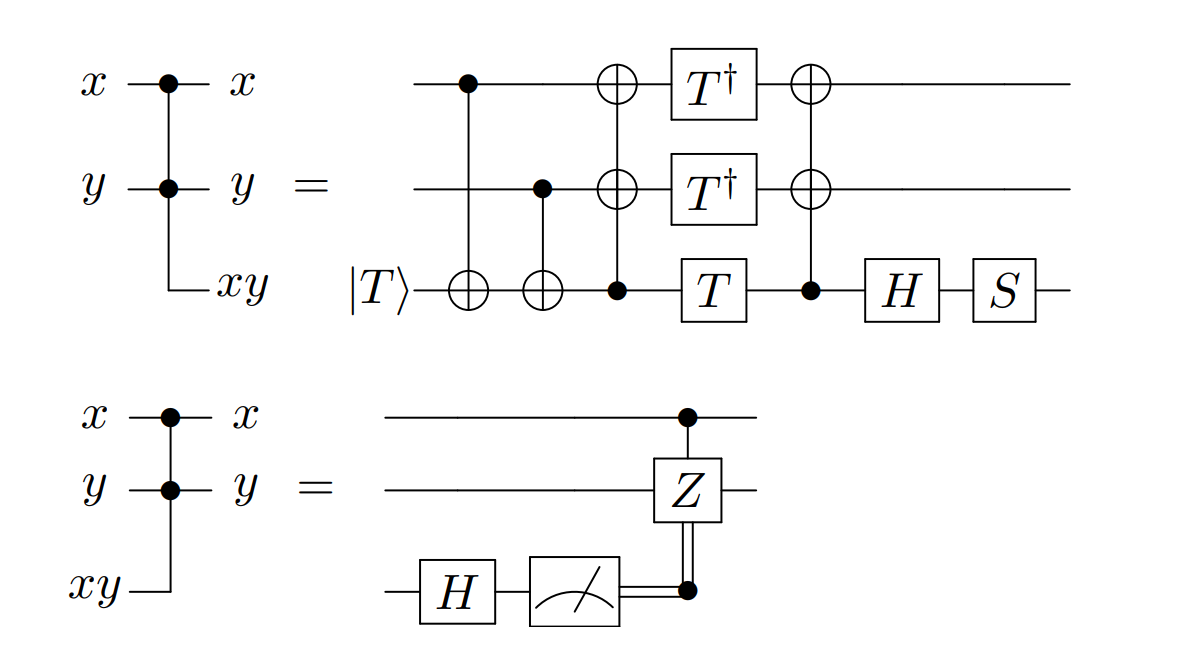

The $AND^{-1}$ implementation is particularly unique as it uses classical measurement to skip practically every expensive operation used in the $AND$ implementation. The phase is preserved by a $CZ$ controlled on the result of the measurement.

In [ ]:
def AND():
  #[a b T] -> [a b a&b]
  qc = QuantumCircuit(3)
  qc.cx(0, 2)
  qc.cx(1, 2)
  qc.cx(2, [0,1])
  qc.tdg([0,1])
  qc.t(2)
  qc.cx(2, [0,1])
  qc.h(2)
  qc.s(2)
  return qc.to_gate(label='ADD')

def ANDdg():
  #[a b a&b] -> [a b 0]
  qc = QuantumCircuit(3,1)
  qc.h(2)
  qc.measure(2,0)
  with qc.if_test((0, 1)):
    qc.cz(0, 1)
    qc.x(2)
  return qc

### Testing $AND$ and $AND^{-1}$

In [ ]:
#| test
qc = QuantumCircuit(3,3)
qc.h(2)
qc.t(2)
qc.x(0)
qc.x(1)
qc.compose(AND(), qubits=[0,1,2], inplace=True)
qc.measure([0,1,2], [0,1,2])
assert run(qc,8) == {'111': 8}, "AND gate does not work correctly"

qc = QuantumCircuit(3,3)
qc.h(2)
qc.t(2)
qc.x(0)
qc.compose(AND(), qubits=[0,1,2], inplace=True)
qc.compose(ANDdg(), qubits=[0,1,2], clbits=[0], inplace=True)
qc.measure([0,1,2],[0,1,2])
assert run(qc,8) == {'001': 8}, "ANDdg fails to undo AND gate"

In [ ]:
def AdderBlock(constant_bit):
  qc = QuantumCircuit(3)
  if constant_bit:
    qc.x(0)
    qc.x(1)
  qc.append(AND(), [0,1,2])
  if constant_bit:
    qc.x(2)
  return qc.to_gate(label='add_block')


def AdderBlockUncompute_op(constant_bit):
  qc = QuantumCircuit(3, 1)
  if constant_bit:
    qc.x(2)
  qc.compose(ANDdg(), qubits=[0,1,2], clbits=[0], inplace=True)
  if constant_bit:
    qc.x(0)
  qc.cx(0,1)

  return qc

In [ ]:
def convertToBits(i, padding=0):
  #returns padded list of bits in big-endian
  i_bitstr = bin(i)[2:]
  return [int(i) for i in i_bitstr[::-1]]+[0 for i in range(padding-len(i_bitstr))]

#base cases for size=1,2,3 must be done by hand
#luckily, these cases are simple
def ConstantAdder_Size1(constant):
  a = convertToBits(constant,1)
  qc = QuantumCircuit(1)
  if a[0] == 1:
    qc.x(0)
  return qc

def ConstantAdder_Size2(constant):
  a = convertToBits(constant,2)
  qc = QuantumCircuit(2)
  if a[1] == 1:
    qc.x(1)
  qc.cx(0,1)
  if a[0] == 1:
    qc.x(0)
  return qc

def ConstantAdder_Size3(constant):
  a = convertToBits(constant,3)
  qc = QuantumCircuit(3)
  if a[1] == 1:
    qc.x(0)
    qc.x(1)
  qc.mcx([0,1], 2)
  if a[1] == 1:
    qc.x(0)
  qc.cx(0,1)
  if a[0] == 1:
    qc.x(0)
  if a[2]+a[1] == 1: #XOR
    qc.x(2)
  return qc

Algorithmically generalized implementation, following the fully-optimized Adder Design from the paper, shown below:
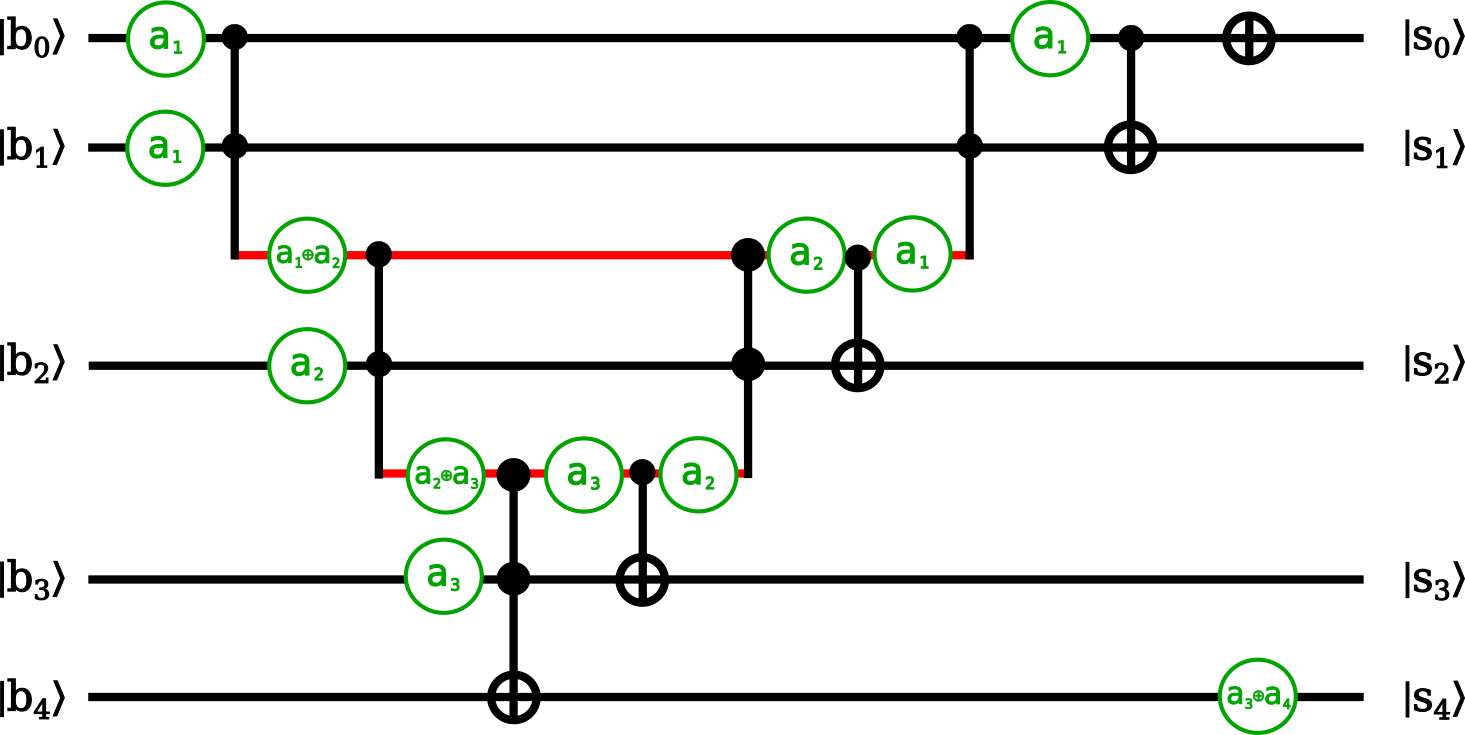

In [ ]:
def ConstantAdder_SizeN(constant, size):
  a = convertToBits(constant, size)

  b = QuantumRegister(size)
  ancilla = QuantumRegister(size-3)
  cl = ClassicalRegister(1)
  qc = QuantumCircuit(b,ancilla,cl)

  qc.h(ancilla)
  qc.t(ancilla)
  qc.append(AdderBlock(a[1]), [b[0],b[1],ancilla[0]])
  for i in range(1, size-3):
    qc.append(AdderBlock(a[i+1]), [ancilla[i-1],b[i+1],ancilla[i]])

  if a[-2] == 1:
    qc.x(b[-2])
    qc.x(ancilla[-1])
  qc.mcx([ancilla[-1], b[-2]], b[-1])
  if a[-2] == 1:
    qc.x(ancilla[-1])
  qc.cx(ancilla[-1], b[-2])
  if a[-1] + a[-2] == 1:
    qc.x(b[-1])

  for i in range(1, size-3)[::-1]:
    qc.compose(AdderBlockUncompute_op(a[i+1]), qubits=[ancilla[i-1],b[i+1],ancilla[i]], clbits=cl, inplace=True)
  qc.compose(AdderBlockUncompute_op(a[1]), qubits=[b[0],b[1],ancilla[0]], clbits=cl, inplace=True)
  if a[0] == 1:
    qc.x(0)

  return qc

### Fedoriaka Adder Export

In [ ]:
#| export
def FedoriakaConstantAdder(constant: int, size: int) -> QuantumCircuit:
  """
  Implements |b> -> |(b + a) mod 2^N> v
    Where a is a fixed classical constant
    Via the method outlined in:
     "New Circuit for Quantum Adder by Constant" (Dmytro Fedoriaka)

  Args:
    constant (int):
      Fixed classical value to add, where 0 <= constant < 2^size a
    size (int):
      Number of qubits in the register b (0<size)

  Result:
    QuantumCircuit object implementing in-place constant addition
    Takes size-3 additional ancillae qubits (or 0 for size<4)  and 1 classical bit (used in uncomputation through venting)
    Can be applied to circuits via .compose()  - .append() will not work

  Circuit Register Layout:
    [ input_qubits | ancillae_qubits ] [ venting_clbit ]
  """
  if size == 1:
    return ConstantAdder_Size1(constant)
  if size == 2:
    return ConstantAdder_Size2(constant)
  if size == 3:
    return ConstantAdder_Size3(constant)
  return ConstantAdder_SizeN(constant, size)

### Testing Fedoriaka Adder

In [ ]:
#| test
qc = QuantumCircuit(2,2)
qc.x(1)
qc.compose(FedoriakaConstantAdder(3,2), qubits=[0,1])
qc.measure([0,1], [0,1])
assert run(qc,8) == {'10': 8}, "ConstantAdder_Size2 does not work correctly"

qc = QuantumCircuit(5,4)
qc.x(0)
qc.x(1)
qc.compose(FedoriakaConstantAdder(5,4), qubits=[0,1,2,3,4], clbits=[0], inplace=True)
qc.measure([0,1,2,3], [0,1,2,3])
assert run(qc,8) == {'1000': 8}

qc = QuantumCircuit(7,5)
qc.compose(FedoriakaConstantAdder(6,5), qubits=[0,1,2,3,4,5,6], clbits=[0], inplace=True)
qc.compose(FedoriakaConstantAdder(2,5), qubits=[0,1,2,3,4,5,6], clbits=[0], inplace=True)
qc.measure([0,1,2,3,4], [0,1,2,3,4])
assert run(qc,8) == {'01000': 8}

In [ ]:
def ControlledAdderBlock(constant_bit):
  qc = QuantumCircuit(4)
  if constant_bit:
    qc.x(1)
    qc.cx(0,2)
  qc.append(AND(), [1,2,3])
  if constant_bit:
    qc.x(3)
  return qc.to_gate(label='add_block')


def ControlledAdderBlockUncompute_op(constant_bit):
  qc = QuantumCircuit(4, 1)
  if constant_bit:
    qc.x(3)
  qc.compose(ANDdg(), qubits=[1,2,3], clbits=[0], inplace=True)
  if constant_bit:
    qc.x(1)
  qc.mcx([0,1],2)

  return qc

In [ ]:
def Controlled_ConstantAdder_Size1(constant):
  a = convertToBits(constant,1)
  qc = QuantumCircuit(2)
  if a[0] == 1:
    qc.cx(0,1)
  return qc

def Controlled_ConstantAdder_Size2(constant):
  a = convertToBits(constant,2)
  qc = QuantumCircuit(3)
  if a[1] == 1:
    qc.cx(0,2)
  qc.mcx([0,1],2)
  if a[0] == 1:
    qc.cx(0,1)
  return qc

Generalizing the Control-Adder design shown in the paper:
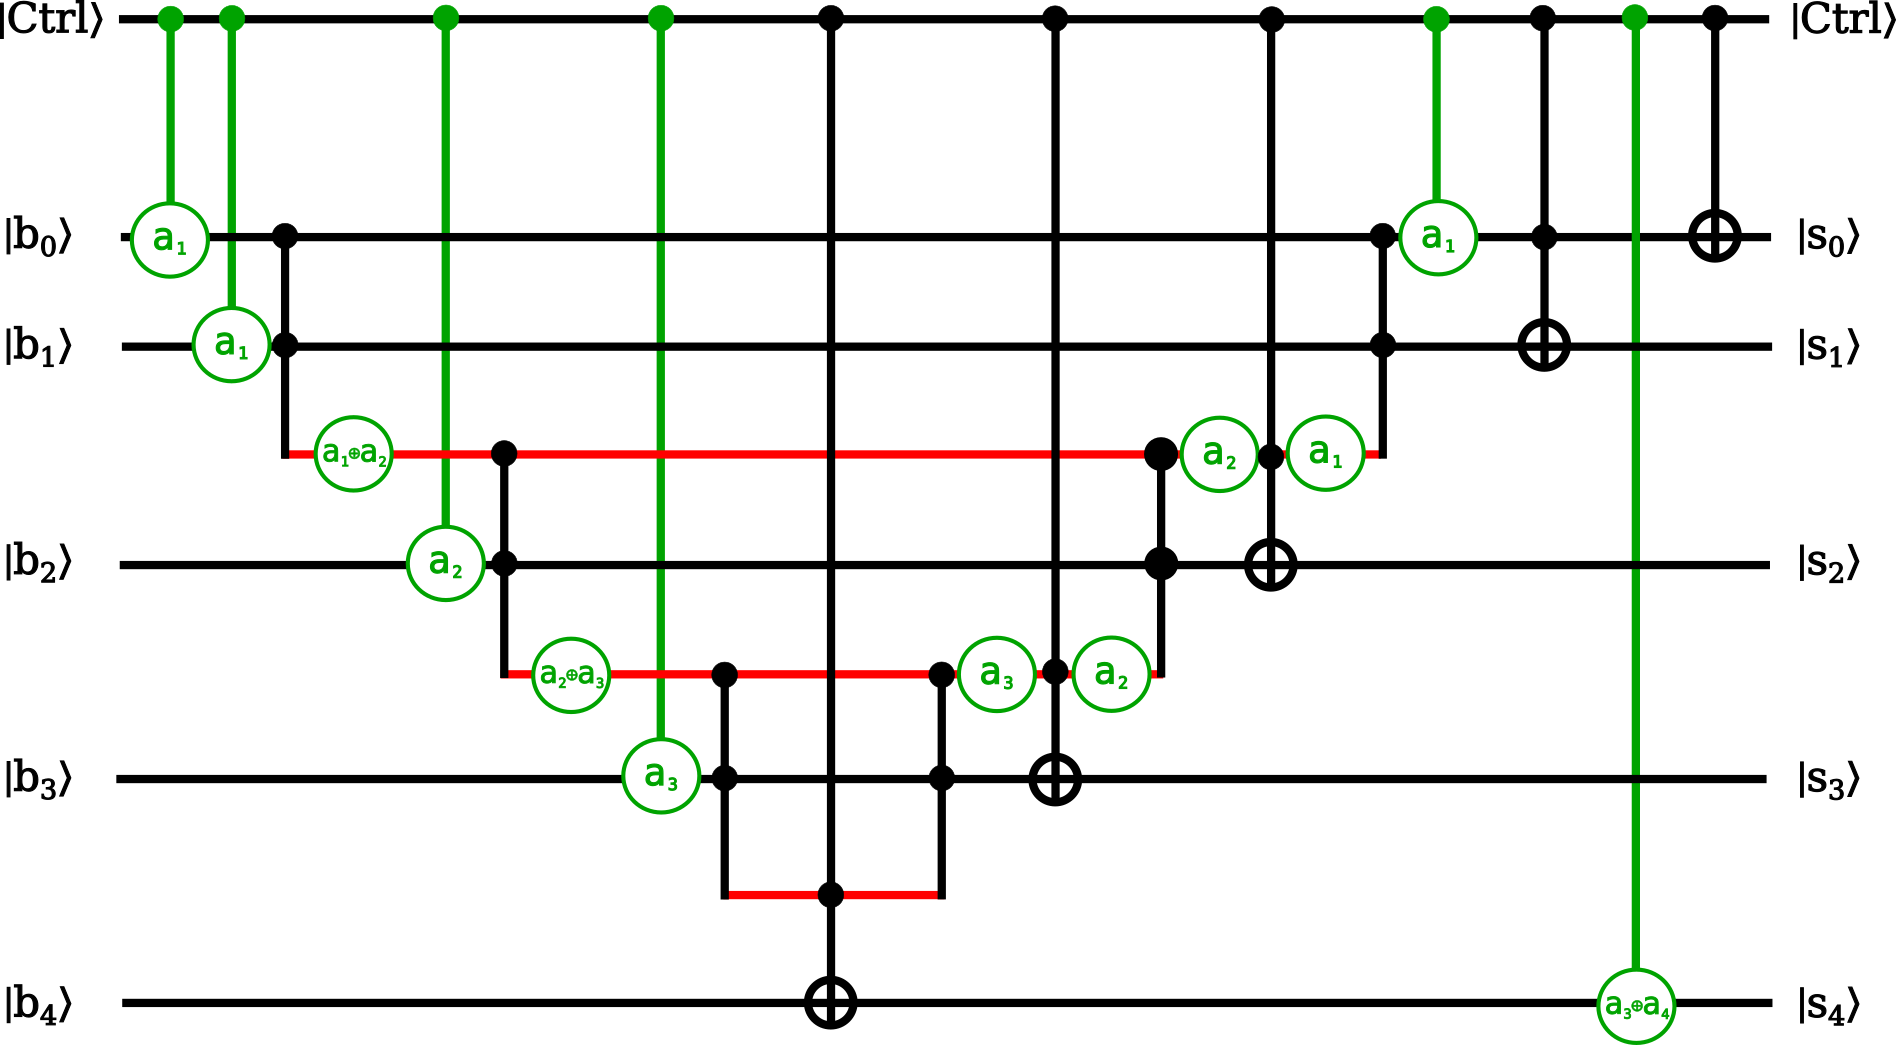

In [ ]:
def Controlled_ConstantAdder_SizeN(constant, size):
  a = convertToBits(constant, size)

  control = [0]
  b = [1+i for i in range(0,size)]
  ancilla = [1+size+i for i in range(0,size-2)]
  qc = QuantumCircuit(2*size-1, 1)

  qc.h(ancilla)
  qc.t(ancilla)

  if a[1] == 1:
    qc.cx(control[0], b[0])
    qc.cx(control[0], b[1])
  qc.compose(AND(), qubits=[b[0],b[1],ancilla[0]], inplace=True)
  if a[1] == 1:
    qc.x(ancilla[0])

  for i in range(1,size-2):
    qc.compose(ControlledAdderBlock(a[i+1]), qubits=[control[0],ancilla[i-1], b[i+1], ancilla[i]],inplace=True)

  if a[-2] == 1:
    qc.x(ancilla[-1])
  qc.mcx([control[0], ancilla[-1]], b[-1])
  if a[-2] == 1:
    qc.x(ancilla[-1])
  for i in range(1,size-2)[::-1]:
    qc.compose(ControlledAdderBlockUncompute_op(a[i+1]), qubits=[control[0], ancilla[i-1], b[i+1], ancilla[i]], clbits=[0], inplace=True)

  if a[1] == 1:
    qc.x(ancilla[0])
  qc.compose(ANDdg(), qubits=[b[0],b[1],ancilla[0]], clbits=[0], inplace=True)
  if a[1] == 1:
    qc.cx(control[0], b[0])
  qc.mcx([control[0],b[0]], b[1])

  if a[-1]+a[-2]==1:
    qc.cx(control[0],b[-1])
  if a[0]==1:
    qc.cx(control[0],b[0])

  return qc

### Controlled Fedoriaka Adder Export

In [ ]:
#| export
def Controlled_FedoriakaConstantAdder(constant, size):
  """
  Implements |c>|b> -> |c>|(b + c*a) mod 2^N>
    Where a is a fixed classical constant
      and c is a quantum control bit
    Via the method for a controlled-adder outlined in:
     "New Circuit for Quantum Adder by Constant" (Dmytro Fedoriaka)

  Args:
    constant (int):
      Fixed classical value to add, where 0 <= constant < 2^size a
    size (int):
      Number of qubits in the register b (0<size)

  Result:
    QuantumCircuit object implementing in-place controlled constant addition
    Takes 1 control bit, size-2 additional ancillae qubits (or 0 for size<3), and 1 classical bit (used in uncomputation through venting)
    Can be applied to circuits via .compose()  - .append() will not work

  Circuit Register Layout:
    [ control_qubit | input_qubits | ancillae_qubits ] [ venting_clbit ]
  """
  if size == 1:
    return Controlled_ConstantAdder_Size1(constant)
  if size == 2:
    return Controlled_ConstantAdder_Size2(constant)
  return Controlled_ConstantAdder_SizeN(constant, size)

### Testing Controlled Fedoriaka Adder

In [ ]:
#| test
qc = QuantumCircuit(3,2)
qc.x(0) #control on
qc.compose(Controlled_FedoriakaConstantAdder(2,2), qubits=[0,1,2], inplace=True)
qc.measure([1,2], [0,1])
assert run(qc,8) == {'10': 8}, "Controlled_ConstantAdder_Size2 does not add properly"

qc = QuantumCircuit(3,2)
#control off
qc.compose(Controlled_FedoriakaConstantAdder(2,2), qubits=[0,1,2])
qc.measure([1,2], [0,1])
assert run(qc,8) == {'00': 8}, "Controlled_ConstantAdder_Size2 is not disabeled by control qubit"

qc = QuantumCircuit(7,4)
#control off
qc.compose(Controlled_FedoriakaConstantAdder(15,4), qubits=[6,0,1,2,3,4,5], clbits=[0], inplace=True)
qc.measure([1,2,3,4], [0,1,2,3])
assert run(qc,8) == {'0000': 8}, "Controlled_ConstantAdder_Size3 is not disabeled by control qubit"

qc = QuantumCircuit(9,5)
qc.x(8)
qc.compose(Controlled_FedoriakaConstantAdder(12,5), qubits=[8,0,1,2,3,4,5,6,7], clbits=[0], inplace=True)
qc.compose(Controlled_FedoriakaConstantAdder(21,5), qubits=[8,0,1,2,3,4,5,6,7], clbits=[0], inplace=True)
qc.measure([0,1,2,3,4], [0,1,2,3,4])
assert run(qc,8) == {'00001': 8}, "Controlled_ConstantAdder_Size3 does not add properly"